In [ ]:
"""
Compute lexical diversity (TTR/STTR) across languages and unit granularities
(words, syllables, phones) from preprocessed corpora.

Overview
--------
This module loads precomputed corpora (pickled Python objects) produced by an
upstream IPA/phonization/syllabification pipeline and computes two measures:

- TTR (Type–Token Ratio): |V| / N over the full sequence.
- STTR (Segmented TTR): mean TTR across fixed-size windows to mitigate TTR's
  length sensitivity.

Data Model
----------
- Words corpus:      List[List[str]]                    (sentences × words)
- Sylls/Phones:      List[List[List[str]]]              (sentences × words × units)

Windows for STTR are constructed over the **flattened** token streams while
preserving sentence/word order (sentence → word → subword unit).

Inputs / Outputs
----------------
Inputs (all must exist for a language to be computed for that unit type):
- <folder>/<LANG>/ipa_corpus_<LANG>_size:<K>.pkl             (words)
- <folder>/<LANG>/sylls/syllabified_<LANG>_size:<K>.pkl      (sylls)
- <folder>/<LANG>/phones/phonized_<LANG>_size:<K>.pkl        (phones)

Outputs:
- Updates 'statistics_summary.csv' in-place, setting the 'STTR' column for
  each (language, unit_type) to the newly computed value (rounded to 4 decimals).

Notes
----------------
- TTR is highly sensitive to corpus length; STTR reduces this sensitivity by
  averaging over fixed-length windows (default 100 tokens) with optional overlap.
"""

from helpers import load_config
import pickle
from pathlib import Path
from typing import Dict, Any
from ipa_conversion import get_largest_ipa_corpus
import pandas as pd

languages = ['FRA', 'DEU', 'ENG']
unit_types = ['sylls', 'phones', 'words']  
folder_name = "produced_data_large_corpus"
corpus_size = 'max'  # 'max' or numeric (int or str of digits)

# ---- your STTR helpers (unchanged) ----
from typing import List, Iterable, Tuple, Optional

def flatten_tokens_words(sentences_words: List[List[str]]) -> List[str]:
    """
    Flatten a corpus of sentences into a single word token stream.

    Parameters
    ----------
    sentences_words : list[list[str]]
        Corpus organized as sentences × words.

    Returns
    -------
    list[str]
        Linearized sequence of word tokens in corpus order.
    """
    return [w for sent in sentences_words for w in sent]

def flatten_tokens_units(sentences_units: List[List[List[str]]]) -> List[str]:
    """
    Flatten a nested units corpus (syllables or phones) into a single stream.

    Parameters
    ----------
    sentences_units : list[list[list[str]]]
        Corpus organized as sentences × words × units.

    Returns
    -------
    list[str]
        Linearized sequence of units in corpus order (sentence → word → unit).
    """
    return [u for sent in sentences_units for word in sent for u in word]

def chunk_seq(tokens: List[str], chunk_size: int, overlap: int = 0) -> List[List[str]]:
    """
    Partition a 1D token sequence into fixed-size, optionally overlapping windows.

    Parameters
    ----------
    tokens : list[str]
        Linearized token stream.
    chunk_size : int
        Length of each window in tokens (must be ≥ 1).
    overlap : int, default=0
        Number of tokens shared between consecutive windows.
        Must satisfy 0 ≤ overlap < chunk_size.

    Returns
    -------
    list[list[str]]
        List of windows, each exactly `chunk_size` tokens long. Any final suffix
        shorter than `chunk_size` is discarded.

    Notes
    -----
    Step size is `chunk_size - overlap`. Use overlap > 0 to increase the number
    of windows and smooth variability in per-window statistics.
    """
    assert 0 <= overlap < chunk_size, "overlap must be in [0, chunk_size)"
    step = chunk_size - overlap
    return [tokens[i:i+chunk_size] for i in range(0, len(tokens) - chunk_size + 1, step)]

def ttr(tokens: Iterable[str]) -> float:
    """
    Compute the Type–Token Ratio (TTR) over the full sequence.

    Parameters
    ----------
    tokens : Iterable[str]
        Token stream.

    Returns
    -------
    float
        |V| / N where |V| is number of distinct token types and N is total
        tokens. Returns NaN if the iterable is empty.

    See Also
    --------
    sttr : Windowed/averaged version of TTR to reduce length dependence.
    """
    tokens = list(tokens)
    if not tokens:
        return float('nan')
    return len(set(tokens)) / len(tokens)

def sttr(tokens: List[str], chunk_size: int = 100, overlap: int = 0) -> Tuple[float, List[float]]:
    """
    Compute Segmented TTR (STTR) as the mean TTR across fixed-size windows.

    Parameters
    ----------
    tokens : list[str]
        Linearized token stream.
    chunk_size : int, default=100
        Length of each window in tokens.
    overlap : int, default=0
        Number of tokens shared by adjacent windows (0 ≤ overlap < chunk_size).

    Returns
    -------
    tuple[float, list[float]]
        (sttr_mean, per_window_ttrs). If the stream is shorter than `chunk_size`,
        returns (NaN, []).

    Notes
    -----
    STTR stabilizes the strong length effect present in raw TTR, enabling more
    comparable values across corpora of different sizes.
    """
    chunks = chunk_seq(tokens, chunk_size=chunk_size, overlap=overlap)
    if not chunks:
        return float('nan'), []
    per_chunk = [ttr(c) for c in chunks]
    return sum(per_chunk) / len(per_chunk), per_chunk

def compute_sttr_across_units(
    sentences_words: Optional[List[List[str]]] = None,
    sentences_sylls: Optional[List[List[List[str]]]] = None,
    sentences_phones: Optional[List[List[List[str]]]] = None,
    chunk_size: int = 100,
    overlap: int = 0
) -> Dict[str, Any]:
    """
    Compute STTR and global TTR for any available unit granularity.

    Parameters
    ----------
    sentences_words : list[list[str]] or None, optional
        Words corpus (sentences × words). If None, 'words' metrics are omitted.
    sentences_sylls : list[list[list[str]]] or None, optional
        Syllables corpus (sentences × words × syllables). If None, 'sylls' omitted.
    sentences_phones : list[list[list[str]]] or None, optional
        Phones corpus (sentences × words × phones). If None, 'phones' omitted.
    chunk_size : int, default=100
        Window length used for STTR.
    overlap : int, default=0
        Overlap between consecutive windows.

    Returns
    -------
    dict
        Mapping from unit type to a metrics dictionary. Keys present are a subset
        of {'words', 'sylls', 'phones'} depending on provided inputs. Each metrics
        dictionary contains:
            - 'num_tokens' : int
            - 'chunk_size' : int
            - 'overlap'    : int
            - 'num_chunks' : int
            - 'STTR'       : float
            - 'global_TTR' : float

    Notes
    -----
    Input corpora are flattened in corpus order before diversity is computed.
    STTR is NaN and 'num_chunks' is 0 when the total tokens < chunk_size.
    """
    results = {}

    if sentences_words is not None:
        tokens_w = flatten_tokens_words(sentences_words)
        sttr_w, ttrs_w = sttr(tokens_w, chunk_size=chunk_size, overlap=overlap)
        results["words"] = {
            "num_tokens": len(tokens_w),
            "chunk_size": chunk_size,
            "overlap": overlap,
            "num_chunks": len(ttrs_w),
            "STTR": sttr_w,
            "global_TTR": ttr(tokens_w)
        }

    if sentences_sylls is not None:
        tokens_s = flatten_tokens_units(sentences_sylls)
        sttr_s, ttrs_s = sttr(tokens_s, chunk_size=chunk_size, overlap=overlap)
        results["sylls"] = {
            "num_tokens": len(tokens_s),
            "chunk_size": chunk_size,
            "overlap": overlap,
            "num_chunks": len(ttrs_s),
            "STTR": sttr_s,
            "global_TTR": ttr(tokens_s)
        }

    if sentences_phones is not None:
        tokens_p = flatten_tokens_units(sentences_phones)
        sttr_p, ttrs_p = sttr(tokens_p, chunk_size=chunk_size, overlap=overlap)
        results["phones"] = {
            "num_tokens": len(tokens_p),
            "chunk_size": chunk_size,
            "overlap": overlap,
            "num_chunks": len(ttrs_p),
            "STTR": sttr_p,
            "global_TTR": ttr(tokens_p)
        }

    return results
# -----------------------------------------------------------------------------
# For each language:
#   1) Resolve the largest available corpus size tag via `get_largest_ipa_corpus`.
#   2) Construct expected pickle paths for words/sylls/phones for that size.
#   3) Load each available unit corpus and compute diversity with
#      `compute_sttr_across_units` (chunk_size=100, overlap=0).
#   4) Update 'statistics_summary.csv' in-place: set 'STTR' for the
#      (language, unit_type) row to the newly computed value (rounded to 4 d.p.).
#
# Assumptions:
# - Pickles conform to the shapes documented above.
# - 'statistics_summary.csv' exists and contains rows for all (language, unit_type)
#   combinations to be updated.
# -----------------------------------------------------------------------------

results_all = {}
for language in languages:
    folder = Path(folder_name) / language
    config_dict = load_config(language)

    expected_size = config_dict['Corpus Size']
    found, is_near_expected, existing_path = get_largest_ipa_corpus(language, expected_size, folder)

    if found: 
        corpus_size = existing_path.stem.split('_')[-1].split(':')[-1]

        phonized_path = Path(folder) / "phones" / f"phonized_{language}_size:{corpus_size}.pkl"
        syllabified_path = Path(folder) / "sylls" / f"syllabified_{language}_size:{corpus_size}.pkl"
        words_path = Path(folder) / f"ipa_corpus_{language}_size:{corpus_size}.pkl"

        # Hold the three unit types for this language if they exist
        lang_data = {"words": None, "sylls": None, "phones": None}

        for unit_type in unit_types:
            print(f"Processing {unit_type} for {language}...")

            # Assign into the correct slot and (optionally) validate shape
            if unit_type == 'sylls':
                path = syllabified_path
            elif unit_type == 'phones':
                path = phonized_path
            elif unit_type == 'words':
                path = words_path

            else:
                raise ValueError(f"❌ Unknown unit type: {unit_type}")
            
            with open(path, "rb") as f:
                data = pickle.load(f)
                print(data[:2])

            lang_data[unit_type] = data
            
        

            # Compute STTRs available for this language (may be a subset if some corpora missing)
            out = compute_sttr_across_units(
                sentences_words=lang_data['words'],
                sentences_sylls=lang_data['sylls'],
                sentences_phones=lang_data['phones'],
                chunk_size=100,
                overlap=0
            )
            results_all[language] = out

            # Pretty-print all results
            from pprint import pprint
            pprint(results_all)

            # Save summary to CSV
            input_csv = Path(folder_name) / "statistics_summary.csv"
            df = pd.read_csv(input_csv)
            df.loc[(df['unit_type'] == unit_type) & (df['language'] == language), 'STTR'] = round(out[unit_type]['STTR'], 4)
            df.to_csv(input_csv, index=False)
            
    else: 
        print(f"❌ No corpus found.")


Processing sylls for FRA...
[[['ʒə'], ['ne'], ['pa'], ['fɛ'], ['la'], ['di', 'fe', 'ʁɑ̃s'], ['ɑ̃tʁ'], ['ø']], [['am', 'lɛt'], ['a', 'ʒi'], ['kɔm'], ['sil'], ['e', 'tɛ'], ['fu']]]
{'FRA': {'sylls': {'STTR': 0.6351391310178349,
                   'chunk_size': 100,
                   'global_TTR': 0.001307484038637159,
                   'num_chunks': 59656,
                   'num_tokens': 5965656,
                   'overlap': 0}}}
Processing phones for FRA...
[[['ʒ', 'ə'], ['n', 'e'], ['p', 'a'], ['f', 'ɛ'], ['l', 'a'], ['d', 'i', 'f', 'e', 'ʁ', 'ɑ̃', 's'], ['ɑ̃', 't', 'ʁ'], ['ø']], [['a', 'm', 'l', 'ɛ', 't'], ['a', 'ʒ', 'i'], ['k', 'ɔ', 'm'], ['s', 'i', 'l'], ['e', 't', 'ɛ'], ['f', 'u']]]
{'FRA': {'phones': {'STTR': 0.2598472388093442,
                    'chunk_size': 100,
                    'global_TTR': 4.761969550606131e-06,
                    'num_chunks': 132298,
                    'num_tokens': 13229820,
                    'overlap': 0},
         'sylls': {'STTR': 0.635139

In [ ]:
"""
Compute per-language corpus size statistics (sentences and unit counts) for IPA-based
datasets and merge them back into an existing summary CSV without creating duplicate
columns.

Overview
--------
1) `get_dataset_size(language, unit_types)`:
   - Locates the largest available IPA corpus for a language (at `corpus_size == "max"`).
   - Loads tokenized corpora for requested unit types (`words`, `sylls`, `phones`).
   - Computes:
       * num_sentences (per-corpus)
       * num_words / num_sylls / num_phones (depending on availability)
       * mean_sentence_length (words per sentence, from word-level corpus)
   - Returns a dictionary keyed by 'language' with the above metrics.

2) Pipeline:
   - Reads `produced_data_large_corpus/statistics_summary.csv`.
   - Derives `languages` to process from the CSV for alignment.
   - Builds a per-language `sizes_df` from `get_dataset_size`.
   - Merges `sizes_df` into the existing table using the most specific available join
     keys; overwrites existing values with fresher ones and appends new columns if needed.
   - Writes the updated table back to the same CSV, restricted to a known schema.

Assumptions
-----------
- Directory layout:
    produced_data_large_corpus/{LANG}/
        ├── {IPA words corpus pickle returned by `get_largest_ipa_corpus`}
        ├── phones/phonized_{LANG}_size:{N}.pkl
        └── sylls/syllabified_{LANG}_size:{N}.pkl

- Data formats:
    * words: List[List[str]]                      # sentence → tokens
    * sylls/phones: List[List[List[str]]]         # sentence → word → subword units

- `helpers.load_config(language)` exposes 'Corpus Size'.
- `syllabification.get_largest_ipa_corpus(lang, expected, folder)` -> (exists, near, Path).

Side Effects
------------
- Reads and writes CSV at: produced_data_large_corpus/statistics_summary.csv

Failure Modes
-------------
- If `corpus_size != "max"`, raises ValueError (supports only 'max').
- If the largest IPA corpus cannot be found/validated, the language is skipped with a warning.
- If any unit-type pickle fails to load, the error is logged and processing continues.
- If the final word-level corpus cannot be loaded or fails structural checks, a ValueError
  is raised (since it is required for mean sentence length).
"""


import pandas as pd
import logging
import pickle
from pathlib import Path
from helpers import load_config
from syllabification import get_largest_ipa_corpus

def get_dataset_size(language, unit_types):
    """
    Compute corpus size statistics for a language across requested unit types and
    return a compact metrics dictionary.

    Parameters
    ----------
    language : str
        ISO 639-3 language code (e.g., 'FRA', 'DEU', 'ENG').
    unit_types : Sequence[str]
        Any subset of {'words', 'sylls', 'phones'} indicating which corpora to load
        for counting. The function will always re-load the word-level corpus at the end
        to compute mean sentence length.

    Uses (Globals)
    --------------
    folder_name : str
        Base directory name containing per-language folders (e.g., "produced_data_large_corpus").
    corpus_size : str
        Must be 'max' in the current implementation.

    Returns
    -------
    dict | None
        A dictionary with at least the key 'language'. Depending on availability of
        corpora, the following keys may be present:
          - 'num_sentences' : int
          - 'num_words'     : int
          - 'num_sylls'     : int
          - 'num_phones'    : int
          - 'mean_sentence_length' : float
        Returns None when an IPA corpus is not available or not near the expected size.

    Computation Details
    -------------------
    - For 'words' corpora (List[List[str]]), counts sentence length in tokens and sums
      over sentences to obtain 'num_words'. 'num_sentences' is set once and reused.
    - For 'sylls' or 'phones' corpora (List[List[List[str]]]), sums subword lengths
      over all words and sentences to obtain 'num_sylls' or 'num_phones'.
    - Mean sentence length is computed on the word-level corpus only:
        mean_sentence_length = total_word_tokens / num_sentences
      Rounded to 4 decimals for stability in CSV outputs.

    Validation & Error Handling
    ---------------------------
    - If `corpus_size != "max"`, raises ValueError (limit of this version).
    - If `get_largest_ipa_corpus` reports missing or not near-expected size, returns None
      and logs a warning.
    - If expected pickle files fail to load, logs an error and continues with remaining
      unit types.
    - The final word-level corpus must load successfully and conform to List[List[str]];
      otherwise a ValueError is raised.

    Notes
    -----
    The function prints light progress information (first item preview, counts per
    unit type, and mean sentence length) to aid interactive runs and quick debugging.
    """
    folder = Path(folder_name) / language
    config_dict = load_config(language)

    if corpus_size != 'max':
        raise ValueError("Only 'max' corpus_size supported in this version")

    largest_corpus_size = config_dict['Corpus Size']
    exists, is_near_expected, ipa_corpus = get_largest_ipa_corpus(language, largest_corpus_size, folder)

    if not exists or not is_near_expected:
        logging.warning(f"❌ No IPA corpus available for {language}. Skipping...")
        return None

    if ipa_corpus:
        size = int(ipa_corpus.stem.split("_size:")[-1])
        print(f"📄 Found data for {language}")
    else:
        raise FileNotFoundError("get_largest_ipa_corpus() did not return expected IPA corpus path")

    results = {"language": language}

    for unit_type in unit_types:
        # Determine file path
        if unit_type == 'words':
            file_path = ipa_corpus
        else:
            subfolder = folder / unit_type
            filename = f"{'syllabified' if unit_type == 'sylls' else 'phonized'}_{language}_size:{size}.pkl"
            file_path = subfolder / filename

        # Load the data
        try:
            with open(file_path, "rb") as f:
                tokenized_data = pickle.load(f)
                print(tokenized_data[:1])
        except Exception as e:
            logging.error(f"❌ Failed to load {unit_type} corpus for {language}: {e}")
            continue

        num_sentences = len(tokenized_data)

        if unit_type == 'words':
            num_units = sum(len(sentence) for sentence in tokenized_data)
        else:  # sylls or phones
            num_units = sum(len(word) for sentence in tokenized_data for word in sentence)

        key = f"num_{unit_type}"
        results[key] = num_units
        results["num_sentences"] = num_sentences  # Only once — same for all

        print(f"🧮 Language: {language} | Num Sentences: {num_sentences:} | Num {unit_type.title()}: {num_units:}")


    # Load the data
    try:
        with open(ipa_corpus, "rb") as f:
            word_level_data = pickle.load(f)
            print(word_level_data[:1])
    except Exception as e:
        raise ValueError(f"❌ Failed to load {ipa_corpus}: {e}")

    # Check the data structure assumption
    if isinstance(word_level_data, list) and all(isinstance(sent, list) for sent in word_level_data):
        if all(isinstance(tok, str) for sent in word_level_data for tok in sent):
            # Compute mean sentence length
            mean_sentence_length = sum(len(sent) for sent in word_level_data) / len(word_level_data)
            # print(f"{language}: Mean sentence length:", round(mean_sentence_length,4))
            results["mean_sentence_length"] = round(mean_sentence_length, 4)
            print(f"🧮 Mean Sent Length: {round(mean_sentence_length, 4):}")
        else:
            raise ValueError("Data structure check failed: not all tokens are strings.")
    else:
        raise ValueError("Data structure check failed: data is not a list of lists.")
    
    print(f"🧮 Mean Sent Length: {round(mean_sentence_length, 4):}")

    return results if len(results) > 1 else None


# Run for one or more languages
languages = ['FRA', 'DEU', 'ENG']  
unit_types = ['phones', 'sylls']
text_types = ['within_words', 'across_sentences']
n_values = [1, 2, 3, 4]
folder_name = "produced_data_large_corpus"
corpus_size = 'max'

# --- Step 1: Load input CSV ---
input_csv = Path(folder_name) / "statistics_summary.csv"
df = pd.read_csv(input_csv)

# --- Step 2: Get unique languages ---
languages = df["language"].unique()

# --- Step 3: Compute sizes per language ---
sizes = []
for lang in languages:
    result = get_dataset_size(lang, unit_types)
    if result:
        sizes.append(result)

sizes_df = pd.DataFrame(sizes)
 
keep_cols = ['language', 'unit_type', 'text_type', 'n', 'total_num_units',
       'total_ngrams', 'unique_ngrams', 'unique_prefixes', 'unique_units',
       'num_sentences', 'STTR', 'mean_sentence_length']

# --- Step 4: Merge sizes_df into df ---
# This block merges freshly computed size metrics (`sizes_df`) back into the existing
# statistics table (`df`) while avoiding duplicate columns and preserving schema.
#
# 1) Join keys:
#    - Prefer the most specific combination among ['language', 'unit_type', 'text_type', 'n']
#      that is present in `sizes_df`. If none are present beyond 'language', fall back to
#      joining on 'language' only.
#
# 2) Overwrite policy:
#    - Left-merge with suffixes ("", "__new"), then for each column provided by `sizes_df`:
#        * If both the original column and its "__new" counterpart exist, coalesce by
#          taking non-null values from "__new" first and drop the "__new" column.
#        * If only the "__new" version exists (column was absent before), rename it back
#          to the original base name to append it to the schema.
#
# 3) Persistence:
#    - Restrict the saved output to the known set of columns (`keep_cols`) that are present
#      after merging. This ensures stable CSV structure and avoids leaking transient
#      columns created during the merge process.
# ---------------------------------------------------------------------------------------

# Decide join keys dynamically (prefer the full key if available)
candidate_keys = ["language", "unit_type", "text_type", "n"]
join_keys = [k for k in candidate_keys if k in sizes_df.columns]
if not join_keys:
    # Fallback: at least language must be present
    join_keys = ["language"]

# Left-merge with suffixes, then coalesce to avoid duplicates
merged_df = df.merge(sizes_df, on=join_keys, how="left", suffixes=("", "__new"))

# For every column coming from sizes_df (excluding join keys):
sizes_cols = [c for c in sizes_df.columns if c not in join_keys]
for col in sizes_cols:
    new_col = f"{col}__new"
    if col in merged_df.columns and new_col in merged_df.columns:
        # Overwrite old values with new when new is not NA
        merged_df[col] = merged_df[new_col].combine_first(merged_df[col])
        merged_df.drop(columns=[new_col], inplace=True)
    elif new_col in merged_df.columns:
        # Column did not exist before; rename __new -> original name
        merged_df.rename(columns={new_col: col}, inplace=True)

# Keep only the requested columns that exist
keep_cols = [
    "language", "unit_type", "text_type", "n",
    "total_num_units", "total_ngrams", "unique_ngrams",
    "unique_prefixes", "unique_units",
    "num_sentences", "STTR", "mean_sentence_length",
]
final_df = merged_df[[c for c in keep_cols if c in merged_df.columns]]
# --- Step 5: Save updated CSV ---
final_df.to_csv(input_csv, index=False)

In [ ]:
"""
Compute and cache corpus and n-gram model statistics across languages,
processing types, and text types.

This module loads tokenized corpora (phones, syllables, or words) and
corresponding n-gram models (n ∈ {1, 2, 3, 4}) to aggregate basic counts
such as total n-grams, unique n-grams, unique prefixes, and unit-set sizes.
It is designed to run tasks in parallel and to cache loaded pickles to
avoid redundant I/O.

Conventions
-----------
- Units:
  A corpus is a 3-level nested sequence: sentences → words → units, where a
  "unit" is a phone, syllable, or word token depending on `processing_type`.

- Models:
  An n-gram model exposes at least:
    • `ngram_counts: Mapping[Any, int]`
    • `total_prefixes: int`
  Older pickles may store the class under the module name "markov_models".
  The custom unpickler `_RenameUnpickler` transparently remaps that to
  "ngram_model" for backward compatibility.

Outputs
-------
A CSV file named `statistics_summary.csv` written under `folder_name`, with
one row per (language, processing_type, text_type, n).
"""

from __future__ import annotations

import logging
import pickle
import sys
from collections import Counter
from itertools import product
from pathlib import Path
from typing import Any, Iterable, List, Mapping, MutableMapping, Optional, Sequence, Tuple, TypedDict, Protocol

import pandas as pd
from joblib import Parallel, delayed

# --------------------  Configuration --------------------

languages: List[str] = ['DEU', 'ENG', 'FRA']  # 'ENG', 'FRA', 'DEU'
processing_types: List[str] = ['phones', 'sylls', 'words']
text_types: List[str] = ['within_words', 'across_sentences']
n_values: List[int] = [1, 2, 3, 4]
folder_name: str = "produced_data_large_corpus"
corpus_size: str | int = 'max'  # 'max' or int

# -------------------- Type helpers --------------------

class NgramModelLike(Protocol):
    """Minimal protocol required from n-gram model pickles."""
    ngram_counts: Mapping[Any, int]
    total_prefixes: int

class StatsRow(TypedDict):
    """Schema for a single statistics row written to the output CSV."""
    language: str
    processing_type: str
    text_type: str
    n: int
    total_num_units: int
    total_ngrams: int
    unique_ngrams: int
    unique_prefixes: int
    unique_units: int

# A corpus is nested as sentences → words → units (phones/syllables/words).
Corpus = Sequence[Sequence[Sequence[str]]]

# -------------------- Caches & compatibility shims --------------------

loaded_data_cache: MutableMapping[str, Corpus] = {}
loaded_model_cache: MutableMapping[str, NgramModelLike] = {}

# Ensure old pickles that reference "markov_models" resolve to current module.
# The target `ngram_model` module must be importable in the environment.
import ngram_model  # noqa: F401
sys.modules.setdefault("markov_models", ngram_model)


def load_pickle_cached(path: Path | str) -> Corpus:
    """
    Load a pickled corpus from disk with memoization.

    Parameters
    ----------
    path : Path | str
        Filesystem path to a pickle containing a nested corpus structure
        of shape: sentences → words → units (strings).

    Returns
    -------
    Corpus
        The loaded corpus object.

    Notes
    -----
    - Results are memoized by the normalized string form of `path`.
    - If different paths refer to identical files, they are treated as
      separate cache entries (keyed by their string paths).
    """
    key = str(path)
    if key not in loaded_data_cache:
        with open(key, "rb") as f:
            loaded_data_cache[key] = pickle.load(f)
    return loaded_data_cache[key]


class _RenameUnpickler(pickle.Unpickler):
    """
    Custom unpickler that remaps legacy module paths during unpickling.

    This allows unpickling models saved under the module name
    ``"markov_models"`` to be resolved as if they were in
    ``"ngram_model"``.

    Notes
    -----
    - Only the module name is remapped; class names are left unchanged.
    - If other legacy module names appear, they are delegated to the
      base implementation and will fail unless resolvable.
    """
    def find_class(self, module: str, name: str) -> Any:
        if module == "markov_models":
            module = "ngram_model"
        return super().find_class(module, name)


def load_model_cached(path: Path | str) -> NgramModelLike:
    """
    Load an n-gram model with backward-compatible unpickling and memoization.

    Parameters
    ----------
    path : Path | str
        Filesystem path to a pickled n-gram model.

    Returns
    -------
    NgramModelLike
        An object exposing at least the attributes required by
        :class:`NgramModelLike` (``ngram_counts``, ``total_prefixes``).

    Notes
    -----
    - Uses :class:`_RenameUnpickler` to remap legacy module names.
    - Results are memoized by the normalized string path.
    """
    key = str(path)
    if key not in loaded_model_cache:
        with open(key, "rb") as f:
            loaded_model_cache[key] = _RenameUnpickler(f).load()
    return loaded_model_cache[key]


# -------------------- Core computation --------------------

def get_stats_for_all_n(
    language: str,
    processing_type: str,
    text_type: str,
    n_values: Iterable[int],
) -> Optional[List[StatsRow]]:
    """
    Compute statistics for all requested n-gram orders for a (language, processing_type, text_type) triple.

    This routine locates the appropriate tokenized corpus for the specified
    `processing_type`, loads it, derives unit counts, and for each `n` in
    `n_values` loads the corresponding n-gram model file, collecting a row
    of summary statistics.

    Parameters
    ----------
    language : str
        ISO 639-3 language code (e.g., "DEU", "ENG", "FRA").
    processing_type : str
        One of {"phones", "sylls", "words"} determining which corpus to load.
    text_type : str
        One of {"within_words", "across_sentences"} determining which model
        family to read.
    n_values : Iterable[int]
        N-gram orders to collect, typically ``[1, 2, 3, 4]``.

    Returns
    -------
    Optional[List[StatsRow]]
        A list of per-n statistics rows; ``None`` if the corpus is absent or
        cannot be loaded.

    Raises
    ------
    ValueError
        If `corpus_size` is not configured as "max" (current implementation
        supports only "max").

    Logging
    -------
    - ``WARNING`` if a corpus or model file is not found (row skipped).
    - ``ERROR`` if unpickling fails for the data or model (row skipped).

    Notes
    -----
    - The function relies on the following external helpers being available
      in the runtime environment:

        * ``load_config(language) -> dict`` providing at least the key
          ``"Corpus Size"``.
        * ``get_largest_ipa_corpus(language, expected_size, folder) -> tuple[bool, bool, Path | None]``
          that returns a boolean for existence and a ``Path`` to the words
          corpus file.
        * A directory layout under ``folder_name / language`` with subfolders
          ``phones/`` and ``sylls/`` containing pickles named:
          - ``phonized_{LANG}_size:{SIZE}.pkl`` for phones
          - ``syllabified_{LANG}_size:{SIZE}.pkl`` for syllables
        * N-gram model pickles named:
          ``{LANG}_{text_type}_markov_model_{n}gram*.pkl`` in the folder
          ``folder / processing_type``.

    - The "words" processing type uses the same file discovered by
      ``get_largest_ipa_corpus``.
    """
    folder = Path(folder_name) / language
    config_dict = load_config(language)

    if corpus_size == 'max':
        largest_corpus_size = config_dict['Corpus Size']
        exists, _, existing_path = get_largest_ipa_corpus(language, largest_corpus_size, folder)
        if not exists or existing_path is None:
            logging.warning("❌ No IPA corpus available for %s. Skipping...", language)
            return None
    else:
        raise ValueError("Only 'max' corpus_size supported in this version")

    existing_corpus_size = int(existing_path.stem.split("_size:")[-1])

    if processing_type == 'phones':
        data_path = folder / "phones" / f"phonized_{language}_size:{existing_corpus_size}.pkl"
    elif processing_type == 'sylls':
        data_path = folder / "sylls" / f"syllabified_{language}_size:{existing_corpus_size}.pkl"
    elif processing_type == 'words':
        data_path = existing_path
    else:
        logging.warning("Unknown processing_type=%r. Skipping %s.", processing_type, language)
        return None

    if not data_path.exists():
        logging.warning("Data for %s not found at %s. Skipping...", language, data_path)
        return None

    try:
        data: Corpus = load_pickle_cached(data_path)
    except Exception as e:
        logging.error("Error loading %s: %s", data_path, e)
        return None

    # Flatten corpus to a sequence of unit tokens.
    units = [unit for sentence in data for word in sentence for unit in word]
    unit_counts = Counter(units)

    result_list: List[StatsRow] = []

    for n in n_values:
        model_candidates = list((folder / processing_type).glob(f"{language}_{text_type}_markov_model_{n}gram*.pkl"))
        if not model_candidates:
            logging.warning("Model for %s, %s, %s, n=%d not found. Skipping...", language, processing_type, text_type, n)
            continue

        model_path = model_candidates[0]
        try:
            model: NgramModelLike = load_model_cached(model_path)
        except Exception as e:
            logging.error("Error loading model from %s: %s", model_path, e)
            continue

        result_list.append(StatsRow(
            language=language,
            processing_type=processing_type,
            text_type=text_type,
            n=int(n),
            total_num_units=len(units),
            total_ngrams=int(sum(model.ngram_counts.values())),
            unique_ngrams=int(len(model.ngram_counts)),
            unique_prefixes=int(model.total_prefixes),
            unique_units=int(len(unit_counts)),
        ))

    return result_list or None


# -------------------- Parallel driver --------------------

# Group tasks by language, processing_type, text_type (n handled inside worker)
tasks: List[Tuple[str, str, str]] = list(product(languages, processing_types, text_types))

# Run in parallel; control verbosity via joblib's 'verbose' (10 shows progress).
results: List[Optional[List[StatsRow]]] = Parallel(n_jobs=4, verbose=10)(
    delayed(get_stats_for_all_n)(lang, proc, txt_type, n_values) for lang, proc, txt_type in tasks
)  # type: ignore[assignment]

# Flatten the nested result lists.
flat_results: List[StatsRow] = [item for sublist in results if sublist is not None for item in sublist]

df = pd.DataFrame(flat_results)
df.to_csv(str(Path(folder_name) / "statistics_summary.csv"), index=False)


In [4]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable, List, Sequence, Tuple
import pandas as pd
from pandas import DataFrame
from pandas.io.formats.style import Styler
from IPython.display import display


# --- Public configuration (kept as variables to mirror your original snippet) ---
FOLDER_NAME: str = "produced_data_large_corpus"
SUMMARY_FILENAME: str = "statistics_summary.csv"

# Columns to visualize with a bar background
BAR_COLUMNS: List[str] = ["total_ngrams", "unique_ngrams", "unique_prefixes", "unique_units"]

# Integer-like columns
INT_COLUMNS: List[str] = [
    "n",
    "total_num_units",
    "total_ngrams",
    "unique_ngrams",
    "unique_prefixes",
    "unique_units",
    "num_sentences",
]

# Float-like columns
FLOAT_COLUMNS: List[str] = ["STTR", "mean_sentence_length"]


def load_summary_csv(folder_name: str, filename: str) -> DataFrame:
    """Load the per-language summary statistics CSV.

    Args:
        folder_name: Base folder that contains the summary file.
        filename: Name of the CSV file (e.g., ``"statistics_summary.csv"``).

    Returns:
        A pandas ``DataFrame`` with at least the following columns:
        ``["language", "unit_type", "text_type", "n", "total_num_units",
        "total_ngrams", "unique_ngrams", "unique_prefixes", "unique_units",
        "num_sentences", "STTR", "mean_sentence_length"]``.

    Notes:
        - The function does not attempt schema validation beyond relying on
          downstream operations; it will raise a ``KeyError`` at use-sites if
          required columns are missing.
        - For large files, consider memory-efficient options (e.g., specifying
          dtypes) if needed.
    """
    path = Path(folder_name) / filename
    return pd.read_csv(path)


def split_by_ngram_order(df: DataFrame) -> Tuple[DataFrame, DataFrame, DataFrame, DataFrame]:
    """Create n-gram–specific subset views (1–4 grams).

    Args:
        df: Input summary table.

    Returns:
        A tuple of four ``DataFrame`` objects: (1-gram, 2-gram, 3-gram, 4-gram).

    Raises:
        KeyError: If column ``"n"`` is missing.
    """
    df_1 = df[df["n"] == 1]
    df_2 = df[df["n"] == 2]
    df_3 = df[df["n"] == 3]
    df_4 = df[df["n"] == 4]
    return df_1, df_2, df_3, df_4


def split_by_processing_type(df: DataFrame) -> Tuple[DataFrame, DataFrame]:
    """Create subset views for phone- and syllable-based processing.

    Args:
        df: Input summary table.

    Returns:
        A tuple (phones_df, sylls_df).

    Raises:
        KeyError: If column ``"unit_type"`` is missing.

    Notes:
        - This function assumes ``unit_type`` entries include at least
          ``"phones"`` and ``"sylls"``. Rows with other ``unit_type`` values
          are not returned here.
    """
    phones = df[df["unit_type"] == "phones"]
    sylls = df[df["unit_type"] == "sylls"]
    return phones, sylls


def split_by_text_granularity(df: DataFrame) -> Tuple[DataFrame, DataFrame]:
    """Create subset views for text granularity.

    Args:
        df: Input summary table.

    Returns:
        A tuple (words_df, sentences_df), filtering by ``text_type`` equality.

    Raises:
        KeyError: If column ``"text_type"`` is missing.

    Important:
        - Your upstream pipeline often uses ``"within_words"`` and
          ``"across_sentences"``. If your data uses those labels, adapt the
          filters accordingly (e.g., replace ``"words"``→``"within_words"``,
          ``"sentences"``→``"across_sentences"``). This function matches exactly
          the literal strings provided here.
    """
    words = df[df["text_type"] == "words"]
    sentences = df[df["text_type"] == "sentences"]
    return words, sentences


def style_language_summary(
    df: DataFrame,
    language: str,
    int_cols: Sequence[str],
    float_cols: Sequence[str],
    bar_cols: Sequence[str],
    float_fmt: str = "{:.3f}",
) -> Styler:
    """Build a styled per-language summary view with mixed numeric formatting.

    Applies integer formatting to ``int_cols``, fixed-decimal formatting to
    ``float_cols``, bar backgrounds to ``bar_cols``, and a caption indicating
    the language. The styling is non-mutating with respect to the input
    ``DataFrame`` and returns a ``Styler`` object suitable for display in
    Jupyter.

    Args:
        df: Full summary table containing rows for multiple languages.
        language: ISO 639-3 language code to display (e.g., ``"DEU"``).
        int_cols: Column names to format as integers (no decimals).
        float_cols: Column names to format with fixed decimals.
        bar_cols: Column names to visualize with a background bar.
        float_fmt: Python format string for floats (default: ``"{:.3f}"``).

    Returns:
        A pandas ``Styler`` configured with per-column formatting and bars.

    Raises:
        KeyError: If required columns are missing from ``df``.

    Notes:
        - Columns not listed in ``int_cols`` or ``float_cols`` retain the
          default display behavior.
        - Bars provide quick visual comparisons across magnitudes within the
          per-language subset, but they are not normalized across languages.
          For cross-language comparability, consider normalization beforehand.
    """
    df_lang = df[df["language"] == language]

    # Build formatters: integers as no-decimal, floats as user-specified pattern
    int_formatters = {col: "{:,.0f}".format for col in int_cols if col in df_lang.columns}
    float_formatters = {col: float_fmt.format for col in float_cols if col in df_lang.columns}

    styled = (
        df_lang.style
        .set_caption(f"Summary for {language}")
        .format(int_formatters)
        .format(float_formatters)
        .bar([c for c in bar_cols if c in df_lang.columns], color="lightblue")
        .set_properties([c for c in bar_cols if c in df_lang.columns], **{"color": "white"})
    )
    return styled


def display_per_language_tables(
    df: DataFrame,
    int_cols: Sequence[str] = INT_COLUMNS,
    float_cols: Sequence[str] = FLOAT_COLUMNS,
    bar_cols: Sequence[str] = BAR_COLUMNS,
    languages: Iterable[str] | None = None,
) -> None:
    """Render styled summary tables for each language in a DataFrame.

    Args:
        df: Full summary table containing multiple languages.
        int_cols: Columns to render as integers (no decimals).
        float_cols: Columns to render with fixed decimal places.
        bar_cols: Columns to highlight with bar backgrounds.
        languages: Optional explicit list of language codes to render. If
            ``None``, the function iterates over the unique values of
            ``df["language"]`` in their observed order.

    Returns:
        None. Displays each ``Styler`` via IPython’s ``display``.

    Raises:
        KeyError: If the ``"language"`` column is absent.
    """
    langs = list(languages) if languages is not None else list(df["language"].unique())
    for lang in langs:
        styled = style_language_summary(
            df=df,
            language=lang,
            int_cols=int_cols,
            float_cols=float_cols,
            bar_cols=bar_cols,
        )
        display(styled)


def main() -> None:
    """End-to-end routine: load data, make common splits, and display summaries.

    Workflow:
        1) Load the summary CSV located at ``FOLDER_NAME/SUMMARY_FILENAME``.
        2) Create common semantic subset views:
            - n-gram order (1–4)
            - processing type (phones, sylls)
            - text granularity (words, sentences)
        3) Display styled per-language tables with mixed numeric formatting.

    Returns:
        None. Produces styled tables as rich outputs in a notebook context.

    Notes:
        - The subset DataFrames are returned by helper functions but not
          displayed automatically here; adapt as needed if you plan to export
          or further analyze them.
        - If your upstream pipeline uses ``"within_words"`` and
          ``"across_sentences"`` for ``text_type``, adjust
          ``split_by_text_granularity`` accordingly.
    """
    df = load_summary_csv(FOLDER_NAME, SUMMARY_FILENAME)

    # Subsets (available to the caller if this is run in a notebook)
    df_1gram, df_2gram, df_3gram, df_4gram = split_by_ngram_order(df)
    df_phones, df_sylls = split_by_processing_type(df)
    df_words, df_sentences = split_by_text_granularity(df)

    # Display styled views per language
    display_per_language_tables(df)


# If running as a script, call main(). In notebooks you can call the functions directly.
if __name__ == "__main__":
    main()


,language,unit_type,text_type,n,total_num_units,total_ngrams,unique_ngrams,unique_prefixes,unique_units,num_sentences,STTR,mean_sentence_length
0,DEU,phones,within_words,1,21711273,21711273,69,1,69,642765,0.285,7.547
1,DEU,phones,within_words,2,21711273,16860540,1806,68,69,642765,0.285,7.547
2,DEU,phones,within_words,3,21711273,12010968,20116,1770,69,642765,0.285,7.547
3,DEU,phones,within_words,4,21711273,7917948,86829,19445,69,642765,0.285,7.547
4,DEU,phones,across_sentences,1,21711273,21711273,69,1,69,642765,0.285,7.547
5,DEU,phones,across_sentences,2,21711273,21068509,2017,69,69,642765,0.285,7.547
6,DEU,phones,across_sentences,3,21711273,20425779,27744,2014,69,642765,0.285,7.547
7,DEU,phones,across_sentences,4,21711273,19783189,200021,27686,69,642765,0.285,7.547
8,DEU,sylls,within_words,1,7891134,7891134,12480,1,12480,642765,0.736,7.547
9,DEU,sylls,within_words,2,7891134,3040401,100010,7802,12480,642765,0.736,7.547


,language,unit_type,text_type,n,total_num_units,total_ngrams,unique_ngrams,unique_prefixes,unique_units,num_sentences,STTR,mean_sentence_length
15,ENG,phones,within_words,1,12899039,12899039,69,1,69,450000,0.288,7.733
16,ENG,phones,within_words,2,12899039,9419146,1378,66,69,450000,0.288,7.733
17,ENG,phones,within_words,3,12899039,5964328,13768,1340,69,450000,0.288,7.733
18,ENG,phones,within_words,4,12899039,3639570,46492,12971,69,450000,0.288,7.733
19,ENG,phones,across_sentences,1,12899039,12899039,69,1,69,450000,0.288,7.733
20,ENG,phones,across_sentences,2,12899039,12449039,1575,67,69,450000,0.288,7.733
21,ENG,phones,across_sentences,3,12899039,11999054,25072,1557,69,450000,0.288,7.733
22,ENG,phones,across_sentences,4,12899039,11549179,199056,24996,69,450000,0.288,7.733
23,ENG,sylls,within_words,1,4818106,4818106,11392,1,11392,450000,0.673,7.733
24,ENG,sylls,within_words,2,4818106,1338213,45425,4398,11392,450000,0.673,7.733


,language,unit_type,text_type,n,total_num_units,total_ngrams,unique_ngrams,unique_prefixes,unique_units,num_sentences,STTR,mean_sentence_length
30,FRA,phones,within_words,1,13229820,13229820,63,1,63,570587,0.260,7.232
31,FRA,phones,within_words,2,13229820,9103192,1649,63,63,570587,0.260,7.232
32,FRA,phones,within_words,3,13229820,5359122,13436,1578,63,570587,0.260,7.232
33,FRA,phones,within_words,4,13229820,3281441,42206,11850,63,570587,0.260,7.232
34,FRA,phones,across_sentences,1,13229820,13229820,63,1,63,570587,0.260,7.232
35,FRA,phones,across_sentences,2,13229820,12659245,2085,63,63,570587,0.260,7.232
36,FRA,phones,across_sentences,3,13229820,12088832,30021,2082,63,570587,0.260,7.232
37,FRA,phones,across_sentences,4,13229820,11518684,237067,29854,63,570587,0.260,7.232
38,FRA,sylls,within_words,1,5965656,5965656,7800,1,7800,570587,0.635,7.232
39,FRA,sylls,within_words,2,5965656,1839028,41588,3659,7800,570587,0.635,7.232


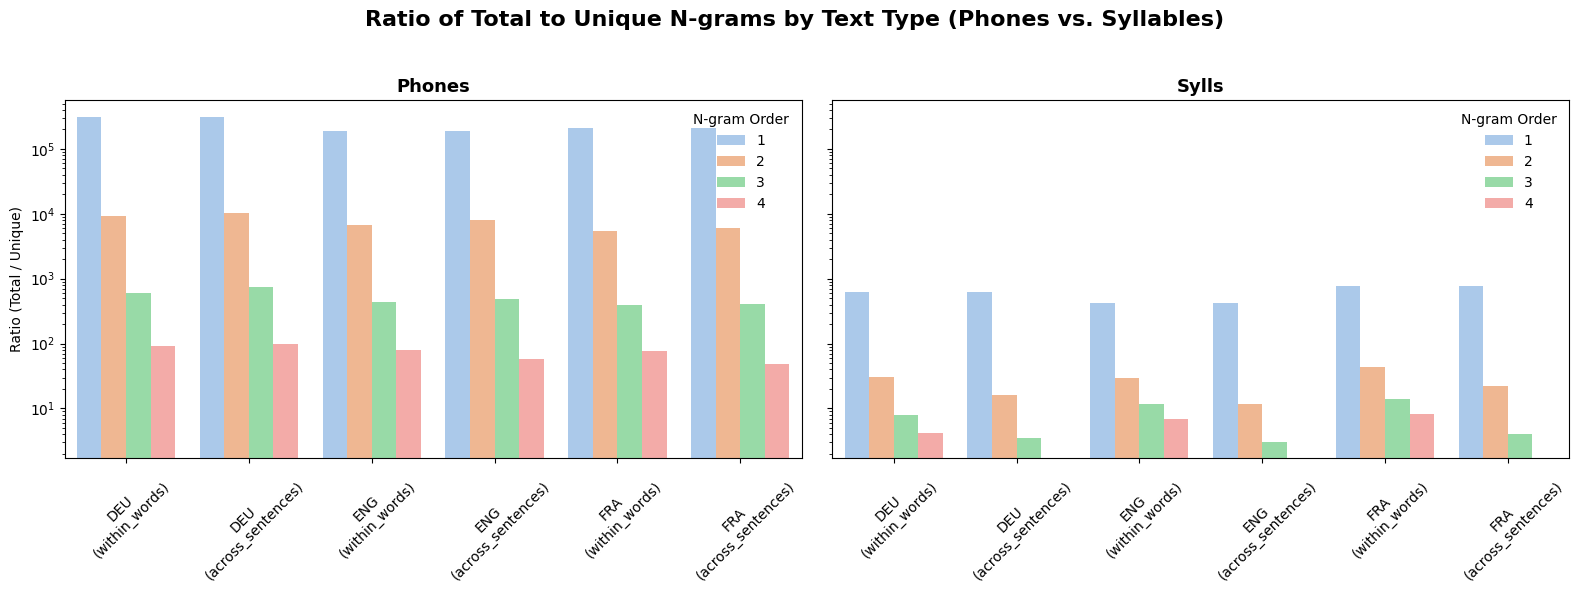

In [11]:
from __future__ import annotations

from typing import Iterable, Tuple, Optional
import numpy as np
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns


def plot_phones_vs_sylls_by_texttype_across_n(
    df: DataFrame,
    n_values: Iterable[int] = (1, 2, 3, 4),
    *,
    palette: Optional[str] = "pastel",
    log_y: bool = True,
    fig_size: Tuple[float, float] = (16.0, 6.0),
) -> Tuple[Figure, np.ndarray]:
    """Plot ratio(total_ngrams / unique_ngrams) across text types and n-gram orders
    for phones vs. syllables, faceted as two side-by-side bar charts.

    This function creates two panels (subplots): the left panel summarizes rows
    with ``unit_type == "phones"`` and the right panel summarizes rows with
    ``unit_type == "sylls"``. Within each panel, bars are grouped by
    ``language × text_type`` (e.g., ``"DEU\\n(across_sentences)"``) and
    the hue encodes the n-gram order ``n``. The height of each bar is the
    mean of the per-row ratio ``total_ngrams / unique_ngrams`` for the
    corresponding group (Seaborn’s ``estimator`` is used for aggregation).

    Args:
        df:
            Long-form summary table containing at least the following columns:
            ``["language", "unit_type", "text_type", "n",
               "total_ngrams", "unique_ngrams"]``.
        n_values:
            Iterable of n-gram orders to include (default: ``(1, 2, 3, 4)``).
        palette:
            Seaborn palette name to use for hues (default: ``"pastel"``).
        log_y:
            If ``True``, the y-axis is log-scaled to stabilize large-ratio ranges.
        fig_size:
            Matplotlib figure size ``(width, height)`` in inches.

    Returns:
        A tuple ``(fig, axes)`` where:
        - ``fig`` is the created :class:`matplotlib.figure.Figure`.
        - ``axes`` is a NumPy array of the two subplot axes
          ``axes[0]`` (phones) and ``axes[1]`` (sylls).

    Raises:
        KeyError:
            If any required columns are missing from ``df``.
        ValueError:
            If no rows remain after filtering by ``n_values`` or ``unit_type``.

    Notes:
        - The ratio is computed per row as
          ``ratio_total_to_unique = total_ngrams / unique_ngrams``.
          Rows with ``unique_ngrams == 0`` are excluded to avoid division by zero.
        - Aggregation uses the mean across rows within each bar group; if you
          prefer a different statistic (e.g., median), pass a different callable
          via Seaborn’s ``estimator`` parameter inside the function body.
        - For cross-language comparability, ensure consistent preprocessing and
          corpus sizes upstream.
    """
    required = {"language", "unit_type", "text_type", "n", "total_ngrams", "unique_ngrams"}
    missing = required.difference(df.columns)
    if missing:
        raise KeyError(f"Input DataFrame is missing required columns: {sorted(missing)}")

    # Filter to requested n values and valid unit_types
    df = df[df["n"].isin(list(n_values))].copy()
    if df.empty:
        raise ValueError("No rows left after filtering by n_values.")

    # Avoid division by zero; drop rows with unique_ngrams == 0
    df = df[df["unique_ngrams"] != 0].copy()
    if df.empty:
        raise ValueError("All rows have unique_ngrams == 0 after filtering; cannot compute ratios.")

    # Prepare figure
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=fig_size, sharey=True)
    panels = [("phones", axes[0]), ("sylls", axes[1])]

    for unit_type, ax in panels:
        df_sub = df[(df["unit_type"] == unit_type)].copy()
        if df_sub.empty:
            raise ValueError(f"No rows found for unit_type == '{unit_type}' after filtering.")

        # Compute ratio per row
        df_sub["ratio_total_to_unique"] = df_sub["total_ngrams"] / df_sub["unique_ngrams"]

        # Group label shown on x-axis: Language + Text Type (line break between)
        df_sub["x_group"] = df_sub["language"] + "\n(" + df_sub["text_type"] + ")"

        sns.barplot(
            data=df_sub,
            x="x_group",
            y="ratio_total_to_unique",
            hue="n",
            estimator=np.mean,   # change to np.median if preferred
            errorbar=None,       # disable CI for cleaner comparison; set to "sd" to show dispersion
            palette=palette,
            ax=ax,
        )

        if log_y:
            ax.set_yscale("log")

        ax.set_title(unit_type.title(), fontsize=13, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Ratio (Total / Unique)" if unit_type == "phones" else "")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(title="N-gram Order", frameon=False)

    fig.suptitle(
        "Ratio of Total to Unique N-grams by Text Type (Phones vs. Syllables)",
        fontsize=16,
        fontweight="bold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig, axes

fig, axes = plot_phones_vs_sylls_by_texttype_across_n(df, n_values=(1,2,3,4))
